<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time

randomseed = 111 

In [7]:
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [8]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [9]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

In [16]:
# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

##### 1.1.1 Sans pénalisation

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



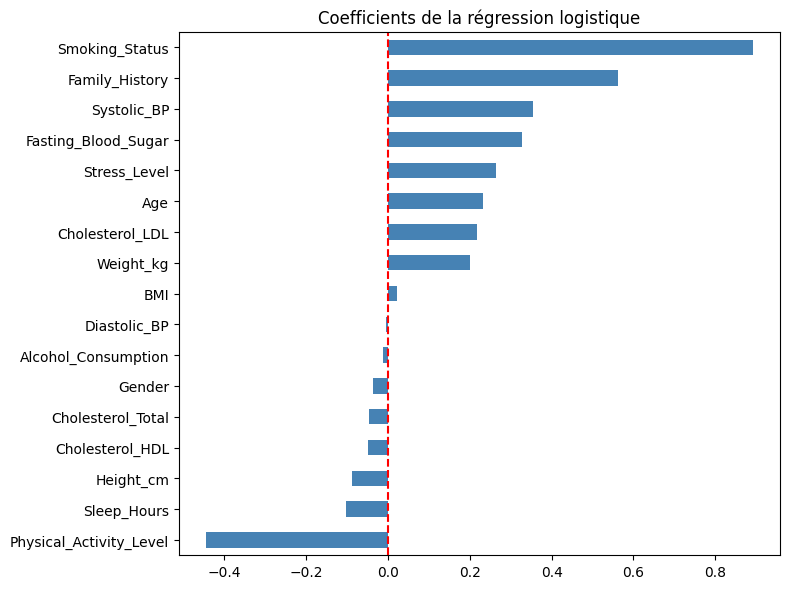

In [25]:
log_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=randomseed)
log_reg.fit(X_train_scaled, y_train)

# Prédictions
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test  = log_reg.predict(X_test_scaled)

# Évaluation des performances
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test))

# Visualisation des coefficients
coef = pd.Series(log_reg.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title("Coefficients de la régression logistique")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


##### 1.1.2 Lasso L1

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifi

C optimal : 21.5443
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000


Variables éliminées (coef = 0) : 0
Variables conservées : 17


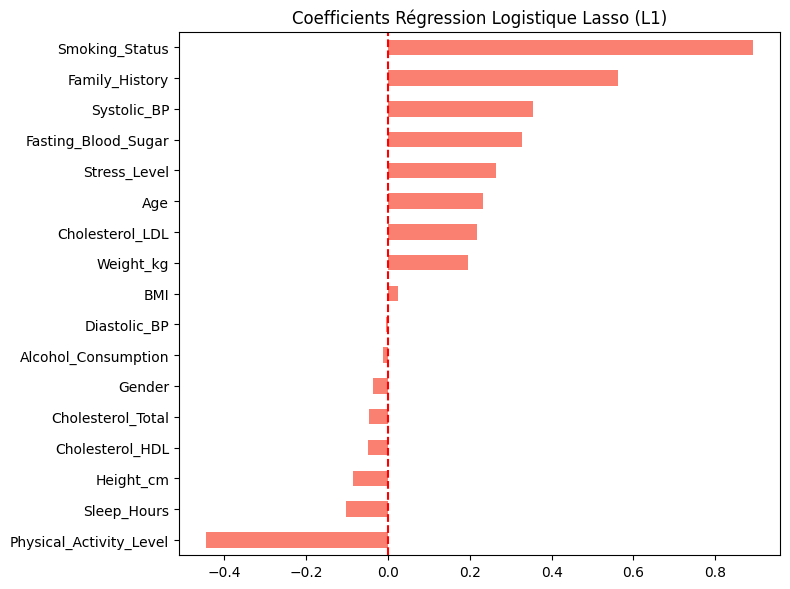

In [26]:
from sklearn.linear_model import LogisticRegressionCV

# ── Régression Logistique avec pénalisation L1 ────────────────
# On utilise LogisticRegressionCV pour optimiser C par validation croisée
# C = 1/lambda (plus C est petit, plus la pénalisation est forte)
log_lasso = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_lasso.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_lasso.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_lasso = log_lasso.predict(X_train_scaled)
y_pred_test_lasso  = log_lasso.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_lasso):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_lasso):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_lasso))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_lasso))

# ── Coefficients (variables sélectionnées) ────────────────────
coef_lasso = pd.Series(log_lasso.coef_[0], index=X.columns)
print(f"\nVariables éliminées (coef = 0) : {sum(coef_lasso == 0)}")
print(f"Variables conservées : {sum(coef_lasso != 0)}")

coef_lasso.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Coefficients Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.3 Ridge L2

In [27]:
# ── Régression Logistique avec pénalisation L2 ────────────────
# L2 est le penalty par défaut de LogisticRegressionCV
log_ridge = LogisticRegressionCV(
    penalty='l2',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_ridge.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_ridge.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_ridge = log_ridge.predict(X_train_scaled)
y_pred_test_ridge  = log_ridge.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_ridge):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_ridge):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_ridge))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_ridge))

# ── Coefficients ────────────────

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifi

C optimal : 2.7826
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



In [28]:
# ── Tableau comparatif des 3 modèles ─────────────────────────
resultats_logit = pd.DataFrame({
    "Modèle": [
        "Logistique (sans pénalisation)",
        "Logistique Lasso (L1)",
        "Logistique Ridge (L2)"
    ],
    "C optimal": ["-", "21.5443", "2.7826"],
    "Accuracy Train": [0.7361, 0.7361, 0.7361],
    "Accuracy Test":  [0.7530, 0.7530, 0.7530],
    "F1-score (classe 1)": [0.69, 0.69, 0.69],
    "Variables éliminées": ["-", "0", "-"]
})

print(resultats_logit.to_string(index=False))

                        Modèle C optimal  Accuracy Train  Accuracy Test  F1-score (classe 1) Variables éliminées
Logistique (sans pénalisation)         -          0.7361          0.753                 0.69                   -
         Logistique Lasso (L1)   21.5443          0.7361          0.753                 0.69                   0
         Logistique Ridge (L2)    2.7826          0.7361          0.753                 0.69                   -
